In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np 

from sklearn.ensemble import RandomForestRegressor  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train = pd.read_csv(r"C:\Users\Kanti\Downloads\archive (4)\train.csv")
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
feature = pd.read_csv(r"C:\Users\Kanti\Downloads\archive (4)\features.csv")

feature.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05-02-2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12-02-2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19-02-2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26-02-2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05-03-2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
train["Date"] = pd.to_datetime(train["Date"], format="mixed", dayfirst=True, errors="coerce")
feature["Date"] = pd.to_datetime(feature["Date"], format="mixed", dayfirst=True, errors="coerce")

In [5]:
store = pd.read_csv(r"C:\Users\Kanti\Downloads\archive (4)\stores.csv")
store.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
df = train.merge(feature, on = ["Store", "Date", "IsHoliday"] , how = "left")
df = df.merge(store, on = "Store", how = "left")

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [7]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

(421570, 16)

In [8]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df["Date"] = pd.to_datetime(df["Date"])                       # Convert Date
df = df.sort_values("Date")                                   # Sort by date
df = df.ffill()
df = df.bfill()                                               # Handle missing values

In [11]:
# Feature Engineering
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df.drop("Date", axis=1, inplace=True)

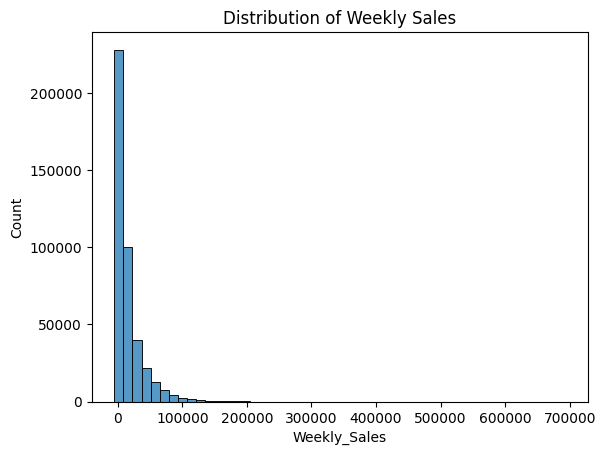

In [12]:
# EDA (Exploratory Data Analysis)
sns.histplot(df["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

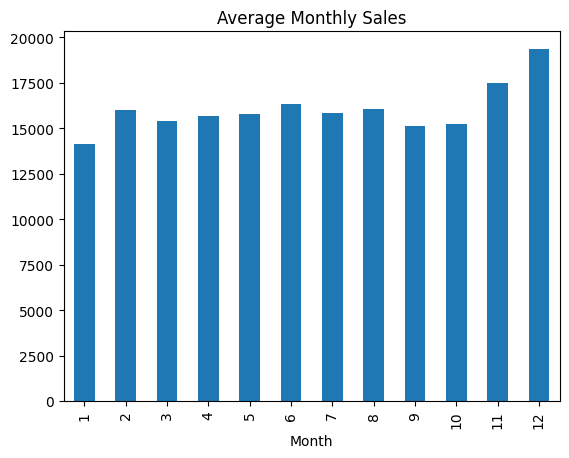

In [13]:
# Monthly Sales (Seasonality)
monthly_sales = df.groupby("Month")["Weekly_Sales"].mean()

monthly_sales.plot(kind="bar")
plt.title("Average Monthly Sales")
plt.show()

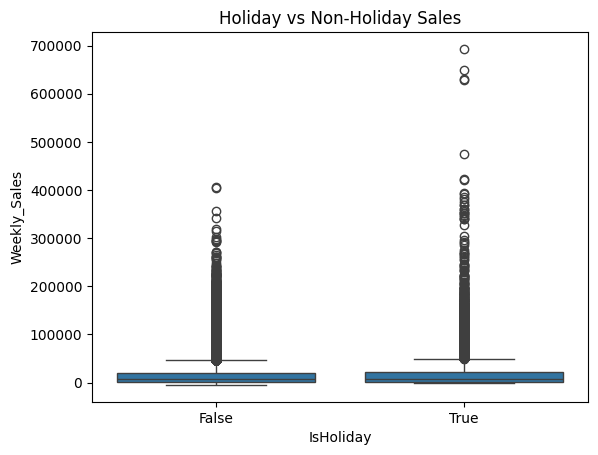

In [14]:
# Holiday vs Non-Holiday Sales
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [15]:
# Encode Categorical Variables
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

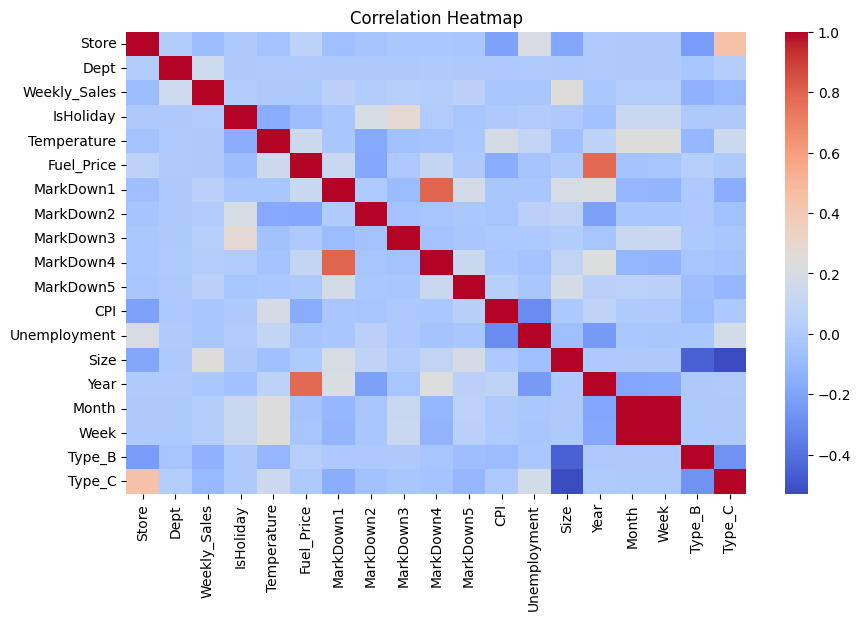

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

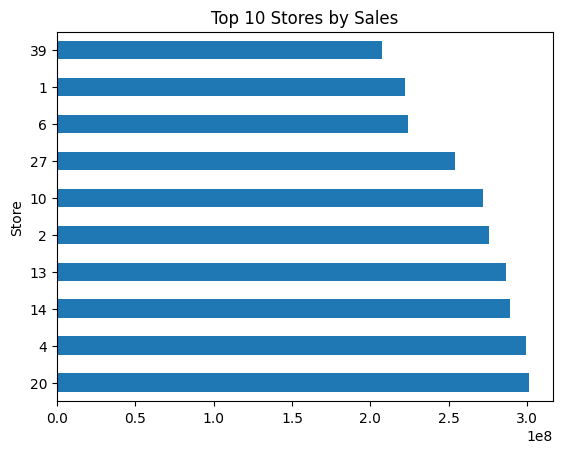

In [17]:
# Top Stores by Sales
top_stores = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10)

top_stores.plot(kind="barh")
plt.title("Top 10 Stores by Sales")
plt.show()

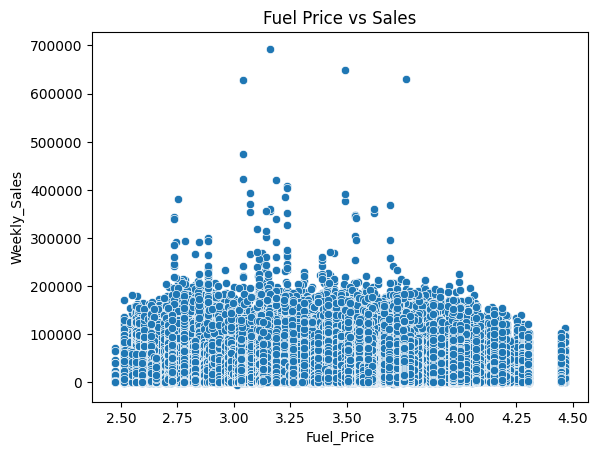

In [18]:
# Fuel Price vs Sales
sns.scatterplot(x="Fuel_Price", y="Weekly_Sales", data=df)
plt.title("Fuel Price vs Sales")
plt.show()

In [19]:
# Define Features & Target
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [20]:
# splite train and test 
# Train/Test Split
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [21]:
model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(X_test)

In [23]:

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4131.701023406824
RMSE: 7167.966084559376
R2 Score: 0.8933307189172788


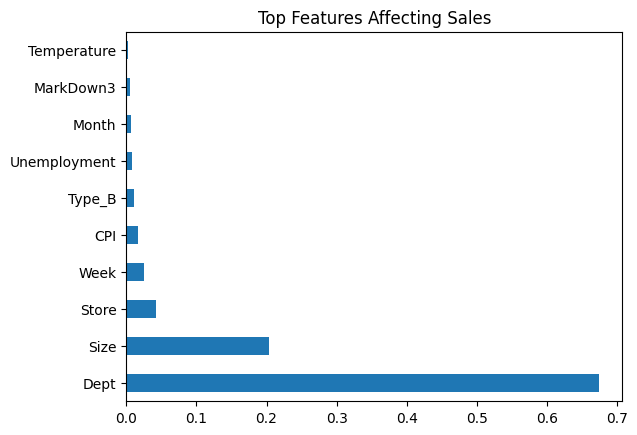

In [24]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Sales")
plt.show()

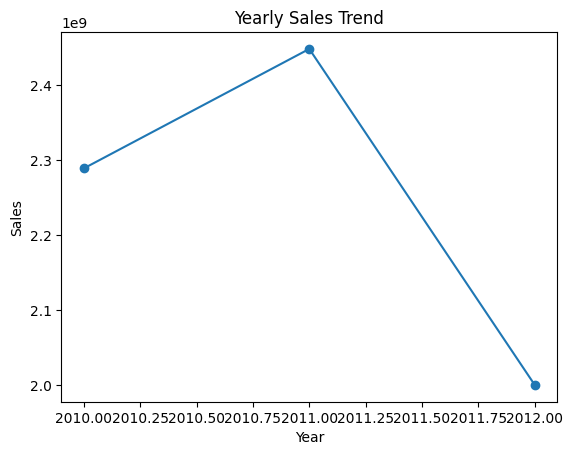

In [25]:
sales_trend = df.groupby("Year")["Weekly_Sales"].sum()

sales_trend.plot(kind="line", marker="o")
plt.title("Yearly Sales Trend")
plt.ylabel("Sales")
plt.show()